In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import squidpy as sq
import enrichmap as em
import pandas as pd
import numpy as np

In [4]:
# set working directory
project_dir = "/home/cenk/Celik_enrichmap/"
working_dir = project_dir + ""
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"

# processed data directory
processed_data = working_dir + "processed_data/"

In [5]:
sc.set_figure_params(frameon=False)
sc.settings._vector_friendly = False

In [6]:
adata = sq.datasets.imc()

In [7]:
adata.X = adata.raw.X.round().astype(np.int64).copy()

In [8]:
from scipy.sparse import issparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats


cell_type = "Basal tumour"
adata.obs["group"] = np.where(
    adata.obs["cell type"] == "basal CK tumor cell",
    cell_type,
    "Rest",
)

# Create pseudo-replicates
# Randomly assign spots to k pseudo-replicates within each group.
# More splits = more power but noisier aggregates. k=3–5 is typical.
k = 3
rng = np.random.default_rng(0)

rep_labels = []
for grp in [cell_type, "Rest"]:
    mask = adata.obs["group"] == grp
    n = mask.sum()
    assignments = rng.integers(0, k, size=n)
    rep_labels.append(
        pd.Series(
            [f"{grp}_rep{i}" for i in assignments],
            index=adata.obs_names[mask],
        )
    )
adata.obs["pseudo_rep"] = pd.concat(rep_labels)

# Aggregate raw counts per pseudo-replicate
counts_mat = adata.X

# densify if sparse
if issparse(counts_mat):
    counts_mat = counts_mat.toarray()

counts_df = pd.DataFrame(
    counts_mat,
    index=adata.obs_names,
    columns=(adata.raw.var_names if adata.raw is not None else adata.var_names),
)
counts_df["pseudo_rep"] = adata.obs["pseudo_rep"]

pseudobulk = counts_df.groupby("pseudo_rep").sum()

# Build sample metadata
sample_meta = pd.DataFrame({"pseudo_rep": pseudobulk.index})
sample_meta["group"] = sample_meta["pseudo_rep"].str.rsplit("_rep", n=1).str[0]
sample_meta = sample_meta.set_index("pseudo_rep")

# Pre-filter low-count genes
gene_keep = pseudobulk.columns[pseudobulk.sum(axis=0) >= 10]
pseudobulk = pseudobulk[gene_keep]

dds = DeseqDataSet(
    counts=pseudobulk,
    metadata=sample_meta,
    design="~group",
    ref_level=["group", "Rest"],
)

dds.deseq2()

stat = DeseqStats(dds, contrast=["group", cell_type, "Rest"])
stat.summary()

results = stat.results_df.copy()

# Filter for upregulated genes in Pyramidal_layer
up = results[(results["padj"] < 0.05) & (results["log2FoldChange"] > 0.5)].sort_values(
    "log2FoldChange", ascending=False
)

print(f"Upregulated genes in {cell_type}: {len(up)}")
print(up.head(10))

tumour_genelist = up.head(5).index.tolist()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 2.24 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...


Log2 fold change & Wald test p-value: group Basal tumour vs Rest
                            baseMean  log2FoldChange     lfcSE       stat  \
1021522Tm169Di EGFR       382.595488        0.110374  0.085940   1.284310   
1031747Er167Di ECadhe    1972.251591       -0.067032  0.041322  -1.622211   
112475Gd156Di Estroge       9.279842       -1.727014  0.805242  -2.144715   
117792Dy163Di GATA3         9.059566       -1.187348  0.774432  -1.533185   
1261726In113Di Histone   5524.902345       -0.189668  0.026668  -7.112275   
1441101Er168Di Ki67       132.426725        0.327421  0.145127   2.256108   
174864Nd148Di SMA         426.507511       -1.120575  0.101727 -11.015541   
1921755Sm149Di Vimenti    591.337971       -1.204518  0.096136 -12.529328   
198883Yb176Di cleaved     603.432667       -0.159341  0.072816  -2.188265   
201487Eu151Di cerbB      1468.224849        0.179951  0.046317   3.885177   
234832Lu175Di panCyto    1857.834245        2.342062  0.176329  13.282336   
3111576Nd14

... done in 1.83 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.05 seconds.



In [9]:
cell_type = "T cells"
adata.obs["group"] = np.where(
    adata.obs["cell type"] == "T cells",
    cell_type,
    "Rest",
)

# Create pseudo-replicates
# Randomly assign spots to k pseudo-replicates within each group.
# More splits = more power but noisier aggregates. k=3–5 is typical.
k = 3
rng = np.random.default_rng(0)

rep_labels = []
for grp in [cell_type, "Rest"]:
    mask = adata.obs["group"] == grp
    n = mask.sum()
    assignments = rng.integers(0, k, size=n)
    rep_labels.append(
        pd.Series(
            [f"{grp}_rep{i}" for i in assignments],
            index=adata.obs_names[mask],
        )
    )
adata.obs["pseudo_rep"] = pd.concat(rep_labels)

# Aggregate raw counts per pseudo-replicate
counts_mat = adata.X

# densify if sparse
if issparse(counts_mat):
    counts_mat = counts_mat.toarray()

counts_df = pd.DataFrame(
    counts_mat,
    index=adata.obs_names,
    columns=(adata.raw.var_names if adata.raw is not None else adata.var_names),
)
counts_df["pseudo_rep"] = adata.obs["pseudo_rep"]

pseudobulk = counts_df.groupby("pseudo_rep").sum()

# Build sample metadata
sample_meta = pd.DataFrame({"pseudo_rep": pseudobulk.index})
sample_meta["group"] = sample_meta["pseudo_rep"].str.rsplit("_rep", n=1).str[0]
sample_meta = sample_meta.set_index("pseudo_rep")

# Pre-filter low-count genes
gene_keep = pseudobulk.columns[pseudobulk.sum(axis=0) >= 10]
pseudobulk = pseudobulk[gene_keep]

dds = DeseqDataSet(
    counts=pseudobulk,
    metadata=sample_meta,
    design="~group",
    ref_level=["group", "Rest"],
)

dds.deseq2()

stat = DeseqStats(dds, contrast=["group", cell_type, "Rest"])
stat.summary()

results = stat.results_df.copy()

# Filter for upregulated genes in Pyramidal_layer
up = results[(results["padj"] < 0.05) & (results["log2FoldChange"] > 0.5)].sort_values(
    "log2FoldChange", ascending=False
)

print(f"Upregulated genes in {cell_type}: {len(up)}")
print(up.head(10))

tcell_genelist = up.head(5).index.tolist()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.04 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.04 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Calculating cook's distance...


Log2 fold change & Wald test p-value: group T cells vs Rest
                            baseMean  log2FoldChange     lfcSE       stat  \
1021522Tm169Di EGFR       240.762772       -0.489309  0.182014  -2.688301   
1031747Er167Di ECadhe    1224.301469       -0.752304  0.122780  -6.127261   
112475Gd156Di Estroge       6.587552       -1.834527  1.057707  -1.734439   
117792Dy163Di GATA3         7.448554       -0.614450  0.793152  -0.774694   
1261726In113Di Histone   3971.993828       -0.311295  0.134459  -2.315163   
1441101Er168Di Ki67        55.273955       -2.395810  0.490644  -4.882995   
174864Nd148Di SMA         868.365524        1.883882  0.168633  11.171511   
1921755Sm149Di Vimenti   1774.639810        2.718603  0.117003  23.235411   
198883Yb176Di cleaved     519.962083        0.292425  0.133460   2.191098   
201487Eu151Di cerbB       851.320549       -0.737109  0.134925  -5.463101   
234832Lu175Di panCyto     368.835059       -2.776082  0.552539  -5.024225   
3111576Nd143Di C

... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.05 seconds.



In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [11]:
signature_dict = {
    "Basal tumour": tumour_genelist,
    "T cell": tcell_genelist
}

In [12]:
em.tl.score(adata, gene_set=signature_dict, n_neighbors=12)

Scoring signatures: 100%|██████████| 2/2 [00:02<00:00,  1.15s/it]


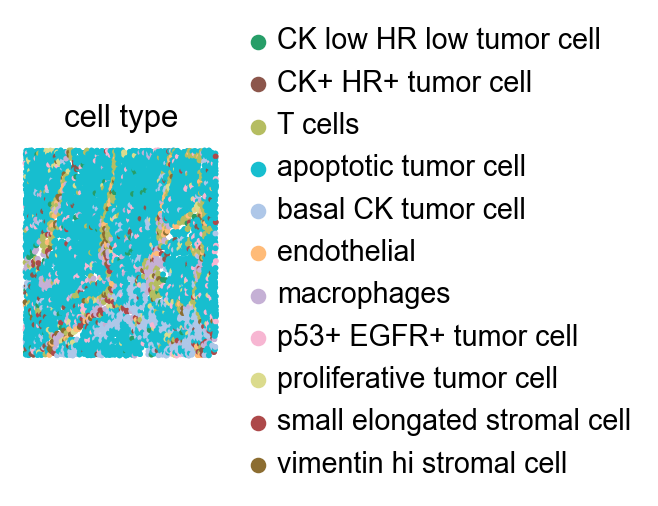

In [13]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color="cell type",
    size=10,
    save="imc_cell_type.pdf",
)

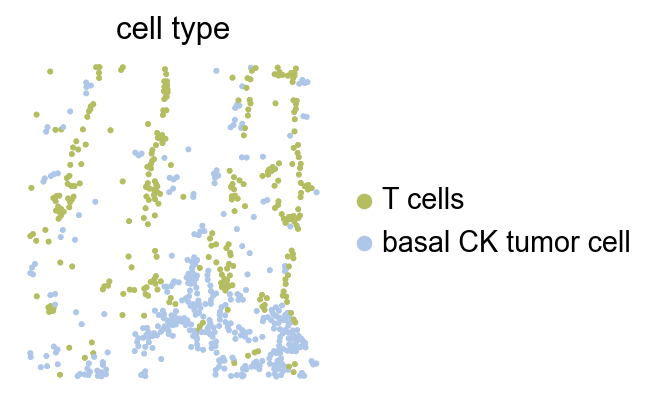

In [14]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color="cell type",
    groups=["basal CK tumor cell", "T cells"],
    size=10,
    save="imc_basal_tumor_cell_tcells.pdf",
)

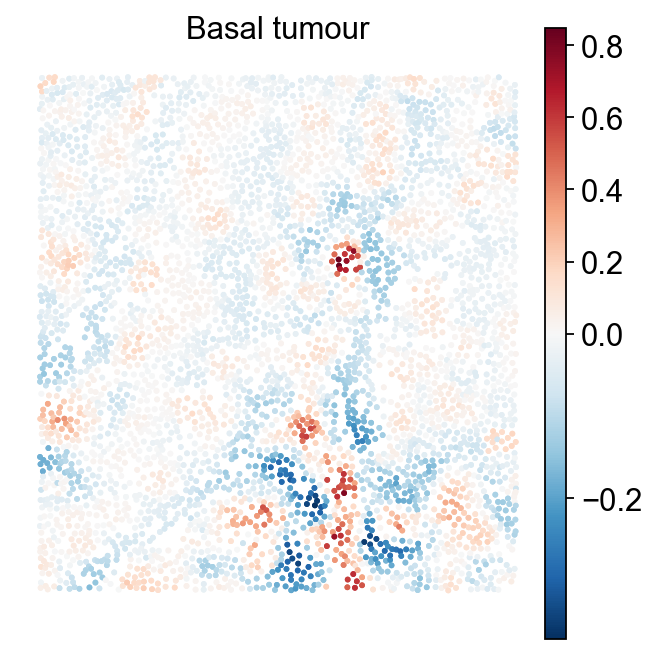

In [15]:
em.pl.spatial_enrichmap(
    adata,
    score_key="Basal tumour_score",
    cmap="RdBu_r",
    shape=None,
    size=10,
    save="imc_enrichmap_score_basal.pdf",
)

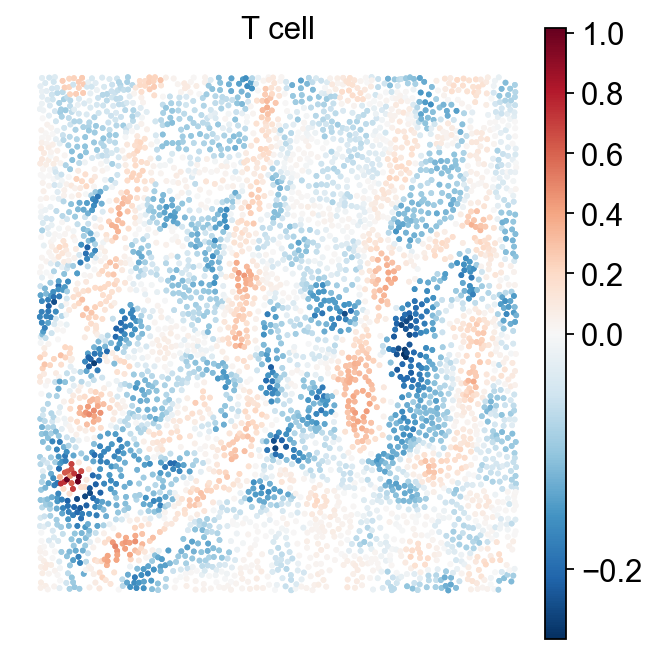

In [16]:
em.pl.spatial_enrichmap(
    adata,
    score_key="T cell_score",
    cmap="RdBu_r",
    shape=None,
    size=10,
    save="imc_enrichmap_score_T_cells.pdf",
)

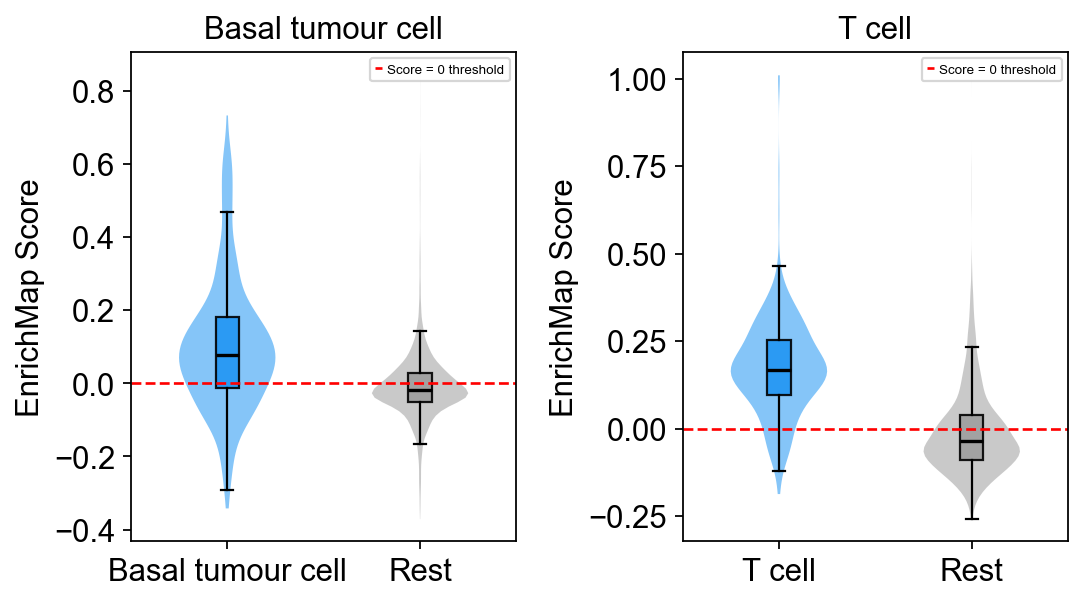

        Cell type  N (GT)  N (rest) % GT score > 0 % Rest score > 0 ROC-AUC Mann-Whitney p
Basal tumour cell     378      4290          72.0%            38.2%   0.720       6.96e-46
           T cell     290      4378          90.0%            36.8%   0.857       1.24e-92


In [17]:
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

eval_pairs = [
    ("Basal tumour cell", ["basal CK tumor cell"], "Basal tumour_score"),
    ("T cell", ["T cells"], "T cell_score"),
]

fig, axes = plt.subplots(1, 2, figsize=(7, 4))
summary_rows = []

for ax, (label, clusters, score_key) in zip(axes, eval_pairs):
    is_target = adata.obs["cell type"].isin(clusters).values
    scores = adata.obs[score_key].values

    target_scores = scores[is_target]
    other_scores = scores[~is_target]

    # 1. Positive fraction (score > 0)
    pos_frac_gt = (target_scores > 0).mean()
    pos_frac_rest = (other_scores > 0).mean()

    # 2. Mann-Whitney U (one-sided: GT scores > Rest scores)
    _, pval = mannwhitneyu(target_scores, other_scores, alternative="greater")

    # 3. ROC-AUC
    auc = roc_auc_score(is_target.astype(int), scores)

    summary_rows.append(
        {
            "Cell type": label,
            "N (GT)": int(is_target.sum()),
            "N (rest)": int((~is_target).sum()),
            "% GT score > 0": f"{pos_frac_gt * 100:.1f}%",
            "% Rest score > 0": f"{pos_frac_rest * 100:.1f}%",
            "ROC-AUC": f"{auc:.3f}",
            "Mann-Whitney p": f"{pval:.2e}",
        }
    )

    colors = ["#2196F3", "#9E9E9E"]
    groups = [target_scores, other_scores]

    # Violin
    vp = ax.violinplot(
        groups,
        positions=[0, 1],
        showmedians=False,
        showextrema=False,
    )
    for pc, color in zip(vp["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.55)

    # Box plot overlay (IQR box + whiskers, no fliers)
    bp = ax.boxplot(
        groups,
        positions=[0, 1],
        widths=0.12,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
        boxprops=dict(linewidth=1),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)

    ax.axhline(
        0, color="red", linestyle="--", linewidth=1.2, label="Score = 0 threshold"
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels([label, "Rest"])
    ax.set_ylabel("EnrichMap Score")
    ax.set_title(label)
    ax.legend(loc="upper right", fontsize=6)
    ax.grid(False)

plt.tight_layout()
plt.savefig(figure_dir + "imc_enrichmap_evaluation.pdf", bbox_inches="tight")
plt.show()

# Summary table
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

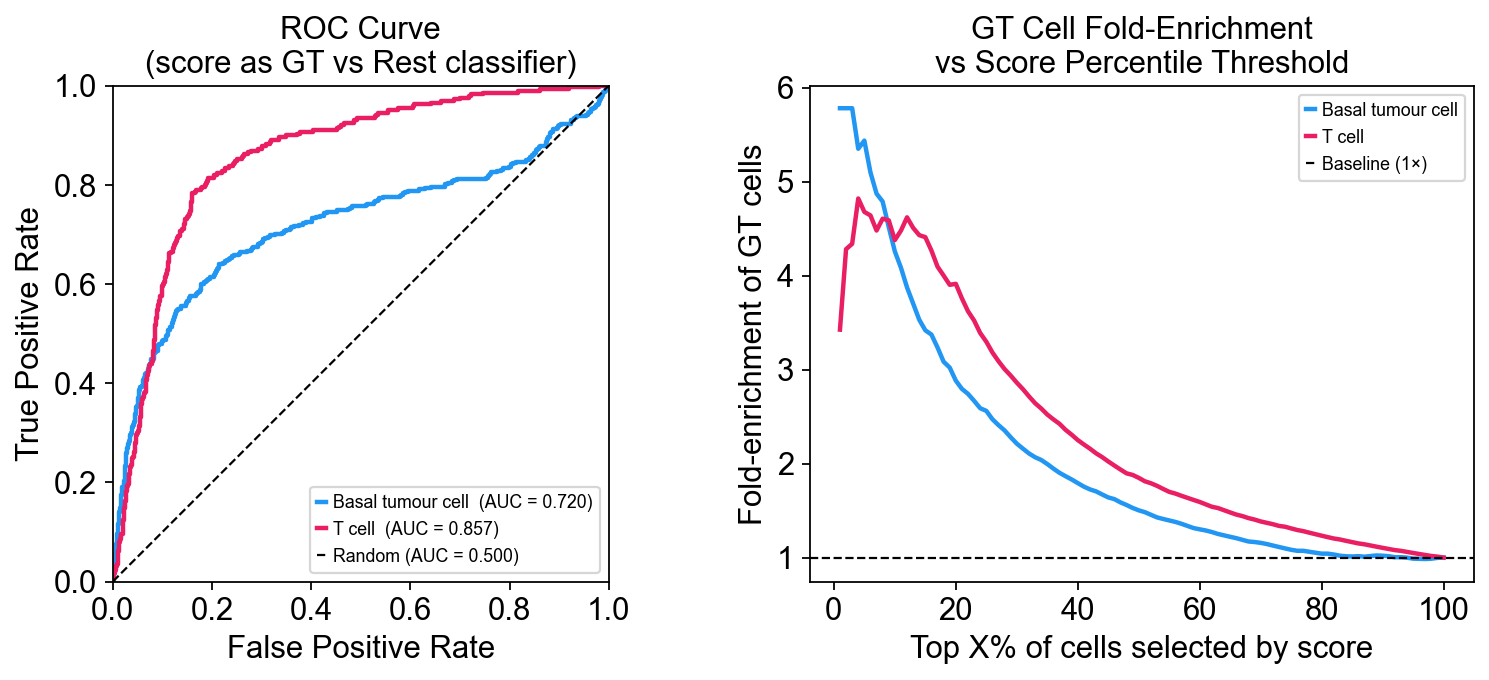

In [18]:
# Supplementary figure: ROC curve + Fold-enrichment vs score percentile
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

palette = {"Basal tumour cell": "#2196F3", "T cell": "#E91E63"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ── Panel A: ROC curves ──────────────────────────────────────────────────────
ax_roc = axes[0]
for label, clusters, score_key in eval_pairs:
    is_target = adata.obs["cell type"].isin(clusters).values.astype(int)
    scores = adata.obs[score_key].values
    fpr, tpr, _ = roc_curve(is_target, scores)
    auc = roc_auc_score(is_target, scores)
    ax_roc.plot(
        fpr, tpr, color=palette[label], linewidth=2, label=f"{label}  (AUC = {auc:.3f})"
    )

ax_roc.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve\n(score as GT vs Rest classifier)")
ax_roc.legend(fontsize=8, loc="lower right")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1)
ax_roc.set_aspect("equal")
ax_roc.grid(False)

# ── Panel B: Fold-enrichment vs score percentile threshold ───────────────────
ax_fe = axes[1]
percentiles = np.arange(1, 101)  # top 1 % … top 100 % of cells by score

for label, clusters, score_key in eval_pairs:
    is_target = adata.obs["cell type"].isin(clusters).values
    scores = adata.obs[score_key].values
    baseline = is_target.mean()  # expected GT fraction across all cells

    fold_enrichments = []
    for pct in percentiles:
        threshold = np.percentile(scores, 100 - pct)  # top pct %
        selected = scores >= threshold
        if selected.sum() == 0:
            fold_enrichments.append(np.nan)
        else:
            observed = is_target[selected].mean()
            fold_enrichments.append(observed / baseline)

    ax_fe.plot(
        percentiles, fold_enrichments, color=palette[label], linewidth=2, label=label
    )

ax_fe.axhline(1, color="black", linestyle="--", linewidth=1, label="Baseline (1×)")
ax_fe.set_xlabel("Top X% of cells selected by score")
ax_fe.set_ylabel("Fold-enrichment of GT cells")
ax_fe.set_title("GT Cell Fold-Enrichment\nvs Score Percentile Threshold")
ax_fe.legend(fontsize=8)
ax_fe.grid(False)

plt.tight_layout()
plt.savefig(
    figure_dir + "imc_enrichmap_supp_roc_foldenrichment.pdf", bbox_inches="tight"
)
plt.show()